In [392]:
# Import essential libraries for data manipulation and analysis
import pandas as pd  # For dataframes and data processing
import numpy as np   # For numerical operations

In [393]:
# Helper: normalize SUBLOCALITY to keep only neighborhood (not county/borough labels)
BOROUGH_SET = {"manhattan","brooklyn","queens","bronx","staten island"}
COUNTY_KEYWORDS = {"county"}
COUNTY_TO_BOROUGH_LOWER = {
    "new york county": "manhattan",
    "kings county": "brooklyn",
    "queens county": "queens",
    "bronx county": "bronx",
    "richmond county": "staten island",
}

def normalize_sublocality(value: str, borough_value: str|None=None):
    if value is None or (isinstance(value,float) and np.isnan(value)):
        return np.nan
    raw = str(value).strip()
    low = raw.lower()
    if low == "" or low in BOROUGH_SET:
        return np.nan  # pure borough label not a neighborhood
    if any(k in low for k in COUNTY_KEYWORDS):
        # map county to borough, then drop (we keep only neighborhood text)
        mapped = COUNTY_TO_BOROUGH_LOWER.get(low)
        return np.nan
    # If equals borough name from BOROUGH column, drop
    if borough_value and str(borough_value).strip().lower() in BOROUGH_SET and low == str(borough_value).strip().lower():
        return np.nan
    return raw

# NYC Housing Data Cleaning Pipeline (Baseline → Feature Ready)

This notebook produces a fully cleaned, NA‑free baseline dataset and an optional feature-ready dataset for modeling NYC housing prices.

**Pipeline Stages**
1. Load raw source + geocode enrichment data
2. Standardize / normalize core columns (location + numeric + categorical)
3. Merge on coordinates (LATITUDE, LONGITUDE)
4. Canonicalize boroughs (retain SUBLOCALITY as-is, no neighborhood split)
5. Text & numeric sanitation, type coercion
6. Controlled missing-value handling (guarded; then refined cleanup)
7. Residual cleanup (impute selective, remove constants / duplicate columns)
8. Baseline finalization (schema locked, no engineered columns)
9. Feature enhancement (optional: outlier capping, derivations, borough inference from ZIP)
10. Strict NA purge (guarantee zero missing values)
11. Final exports (baseline + feature-ready) + manifests

Use the exported `Resources/NY-House-Dataset-Cleaned.csv` for downstream feature engineering or modeling. The feature-ready file adds derived metrics (e.g., price per sqft, logs).

## NYC Housing Price Data Cleaning & Preparation Workflow

This notebook provides a **step-by-step, professional, and reproducible workflow** for cleaning, merging, and preparing NYC housing price data for analysis and modeling. Each step is clearly marked, explained, and visualized to ensure transparency and interpretability.

**Contents:**
- Data loading and initial inspection
- Standardization and cleaning of key columns
- Merging datasets
- Text and numeric cleaning
- Handling missing values and outliers
- Final selection and export
- Before/after cleaning comparison and interpretation

### 1. Data Loading
Load the original NYC housing dataset and the geocoded extraction dataset.

In [394]:
# Load the original NYC housing dataset and the geocoded extraction dataset
df1 = pd.read_csv('Resources/NY-House-Dataset.csv')  # Main dataset (Kaggle)
df2 = pd.read_csv('Resources/housing_geocode_extraction.csv')  # Enriched with geolocation info
# Display the first few rows of each to verify successful loading
print('First 3 rows of NY-House-Dataset:')
print(df1.head(3))
print('\nFirst 3 rows of geocode extraction:')
print(df2.head(3))

First 3 rows of NY-House-Dataset:
                                   BROKERTITLE            TYPE      PRICE  \
0  Brokered by Douglas Elliman  -111 Fifth Ave  Condo for sale     315000   
1                          Brokered by Serhant  Condo for sale  195000000   
2                       Brokered by Sowae Corp  House for sale     260000   

   BEDS  BATH  PROPERTYSQFT  \
0     2   2.0        1400.0   
1     7  10.0       17545.0   
2     4   2.0        2015.0   

                                             ADDRESS                    STATE  \
0                               2 E 55th St Unit 803       New York, NY 10022   
1  Central Park Tower Penthouse-217 W 57th New Yo...       New York, NY 10019   
2                                   620 Sinclair Ave  Staten Island, NY 10312   

                                        MAIN_ADDRESS  \
0             2 E 55th St Unit 803New York, NY 10022   
1  Central Park Tower Penthouse-217 W 57th New Yo...   
2            620 Sinclair AveStaten Isl

### Data Preview
Display the first few rows and column names to verify successful loading and understand the structure.

### 2. Initial Inspection & Standardization
Check and standardize key columns in both datasets before merging.

In [395]:
# Check and compare the columns in both dataframes to understand structure and alignment
print('Columns in geocode extraction:', df2.columns.tolist())
print('Columns in NY-House-Dataset:', df1.columns.tolist())

Columns in geocode extraction: ['LATITUDE', 'LONGITUDE', 'STATE', 'LOCALITY', 'SUBLOCALITY', 'POSTCODE', 'PROPERTY_CATEGORY', 'GEOCODING_TYPE']
Columns in NY-House-Dataset: ['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE']


In [396]:
# df2[['PROPERTY_CATEGORY', 'GEOCODING_TYPE']].value_counts()
print(df2[['SUBLOCALITY']].value_counts().head(10))  # Display the top 10 sublocalities in the geocode extraction
print(df1[['SUBLOCALITY']].value_counts().head(10))  # Display the top 10 sublocalities in the original dataset

SUBLOCALITY    
Upper East Side    117
Jackson Heights     82
Upper West Side     69
Sheepshead Bay      59
Fort Hamilton       49
Bay Ridge           48
Elmhurst            44
Flatlands           44
Midwood             43
Forest Hills        41
Name: count, dtype: int64
SUBLOCALITY    
New York           1016
Kings County        727
Queens County       684
Queens              555
Richmond County     480
Brooklyn            464
Bronx County        307
New York County     286
The Bronx           184
Staten Island        59
Name: count, dtype: int64


In [397]:
# -------------------------------
# Normalize SUBLOCALITY
# -------------------------------

county_to_borough = {
    "new york": "manhattan",
    "new york county": "manhattan",
    "kings county": "brooklyn",
    "queens county": "queens",
    "richmond county": "staten island",
    "bronx county": "bronx",
    "the bronx": "bronx",
    "brooklyn": "brooklyn",
    "queens": "queens",
    "staten island": "staten island",
}

# Apply normalization to df2
df2["SUBLOCALITY"] = (
    df2["SUBLOCALITY"].str.strip().str.lower().replace(county_to_borough)
)

# Apply normalization to df1 (ensure consistent casing)
df1["SUBLOCALITY"] = df1["SUBLOCALITY"].str.strip().str.title()

# Optional: Add BOROUGH column to df1 (map neighborhoods to boroughs if you have mapping)
# Example for Manhattan neighborhoods
neighborhood_to_borough = {
    "Upper East Side": "manhattan",
    "Upper West Side": "manhattan",
    "Harlem": "manhattan",
    "Midtown East": "manhattan",
    # ... (expand as needed)
}

df1["BOROUGH"] = df1["SUBLOCALITY"].replace(neighborhood_to_borough)

# df2 already has borough from county mapping
df2["BOROUGH"] = df2["SUBLOCALITY"]


In [398]:
# -------------------------------
# Standardize casing
# -------------------------------

# For df1 (neighborhoods)
df1["SUBLOCALITY"] = df1["SUBLOCALITY"].str.strip().str.title()

# For df2 (boroughs / counties)
df2["SUBLOCALITY"] = (
    df2["SUBLOCALITY"]
    .str.strip()
    .str.lower()
    .replace(county_to_borough)   # normalize first
    .str.title()                  # then capitalize nicely
)

# Also make sure BOROUGH is consistent
df1["BOROUGH"] = df1["BOROUGH"].str.title()
df2["BOROUGH"] = df2["BOROUGH"].str.title()


In [399]:
df2[['SUBLOCALITY']].value_counts()

SUBLOCALITY    
Upper East Side    117
Jackson Heights     82
Upper West Side     69
Sheepshead Bay      59
Fort Hamilton       49
                  ... 
Queens Village       1
Randall Manor        1
Red Hook             1
Clifton              1
Allerton             1
Name: count, Length: 173, dtype: int64

In [400]:
# Standardize and clean key location columns before merging datasets
for col in ['SUBLOCALITY', 'STATE']:
    for df in [df1, df2]:
        if col in df.columns:
            df[col] = df[col].fillna('').str.strip().str.lower()

# Map known inconsistencies to standard values
state_map = {
    'new york, ny 10022': 'New York',
    'new york, ny 10019': 'New York',
    'staten island, ny 10312': 'New York',
    'manhattan, ny 10022': 'New York',
}
sublocality_map = {
    'new york county': 'New York County',
    'richmond county': 'Richmond County',
    'manhattan': 'Manhattan',
}

for df in [df1, df2]:
    if 'STATE' in df.columns:
        df['STATE'] = df['STATE'].replace(state_map).str.title()  # Capitalize first letter
    if 'SUBLOCALITY' in df.columns:
        df['SUBLOCALITY'] = df['SUBLOCALITY'].replace(sublocality_map).str.title()

# Remove duplicate rows based on coordinates to ensure unique properties
df1 = df1.drop_duplicates(subset=['LATITUDE', 'LONGITUDE'], keep='first')
df2 = df2.drop_duplicates(subset=['LATITUDE', 'LONGITUDE'], keep='first')

print('After cleaning:')
print('df1 shape:', df1.shape)
print('df2 shape:', df2.shape)


After cleaning:
df1 shape: (4200, 18)
df2 shape: (4200, 9)


### Standardize & Clean Key Columns
Standardize and clean key location columns (e.g., SUBLOCALITY, STATE) in both datasets. Remove duplicates based on coordinates to ensure unique properties.

In [401]:
# Safe rename columns for consistency before merging
rename_map = {
    'PROPERTYSQFT': 'SQFT',
    'PROPERTY_CATEGORY': 'PROPERTY_TYPE',
    'SUBLOCALITY_ext': 'SUBLOCALITY',
    'STATE_ext': 'STATE',
    'POSTCODE': 'ZIPCODE',
    'BEDS': 'BEDROOMS',
    'BATH': 'BATHROOMS',
}

for df in [df1, df2]:
    existing_cols = {col: rename_map[col] for col in rename_map if col in df.columns}
    df.rename(columns=existing_cols, inplace=True)

print('Renamed columns in df1:', df1.columns.tolist())
print('Renamed columns in df2:', df2.columns.tolist())


Renamed columns in df1: ['BROKERTITLE', 'TYPE', 'PRICE', 'BEDROOMS', 'BATHROOMS', 'SQFT', 'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE', 'BOROUGH']
Renamed columns in df2: ['LATITUDE', 'LONGITUDE', 'STATE', 'LOCALITY', 'SUBLOCALITY', 'ZIPCODE', 'PROPERTY_TYPE', 'GEOCODING_TYPE', 'BOROUGH']


In [402]:
# Function to audit a dataframe: prints info, head, missing values, and duplicates
def audit_df(df, name="DataFrame"):
    print(f"--- {name} Info ---")
    print(df.info())
    print(f"\n--- {name} Head ---")
    print(df.head())
    print(f"\n--- {name} Missing Values ---")
    print(df.isnull().sum())
    print(f"\n--- {name} Duplicates ---")
    print(df.duplicated().sum())
# Audit both dataframes after cleaning and renaming
audit_df(df1, "Raw Data 1")
audit_df(df2, "Raw Data 2")

--- Raw Data 1 Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4200 entries, 0 to 4800
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4200 non-null   object 
 1   TYPE                         4200 non-null   object 
 2   PRICE                        4200 non-null   int64  
 3   BEDROOMS                     4200 non-null   int64  
 4   BATHROOMS                    4200 non-null   float64
 5   SQFT                         4200 non-null   float64
 6   ADDRESS                      4200 non-null   object 
 7   STATE                        4200 non-null   object 
 8   MAIN_ADDRESS                 4200 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4200 non-null   object 
 10  LOCALITY                     4200 non-null   object 
 11  SUBLOCALITY                  4200 non-null   object 
 12  STREET_NAME                  4200 non-null   object 
 13 

### 3. Merging Datasets
Merge the cleaned Kaggle and geocoded datasets on latitude and longitude to enrich the data.

In [403]:
# -------------------------------
#  Merge datasets on coordinates
# -------------------------------
merged_df = pd.merge(
    df1, df2,
    on=['LATITUDE', 'LONGITUDE'],
    how='inner',
    suffixes=('_orig', '_ext')
)
print(f"Merged shape: {merged_df.shape} (df1: {df1.shape}, df2: {df2.shape})")

Merged shape: (4200, 25) (df1: (4200, 18), df2: (4200, 9))


In [404]:
merged_df[['SUBLOCALITY_orig', 'SUBLOCALITY_ext']].value_counts().head(10)

SUBLOCALITY_orig  SUBLOCALITY_ext
New York                             499
Queens County                        451
Richmond County                      411
Kings County                         291
Bronx County                         240
New York County                      204
Queens                               192
Brooklyn                             133
The Bronx                             86
New York          Upper East Side     85
Name: count, dtype: int64

In [405]:


# -------------------------------
# Normalize common numeric column names
# -------------------------------
# Map known variants to standardized column names
rename_candidates = {
    'PROPERTYSQFT': 'SQFT', 'PROPERTYSQFT_orig': 'SQFT', 'PROPERTYSQFT_ext': 'SQFT',
    'BEDS': 'BEDROOMS', 'BEDS_orig': 'BEDROOMS', 'BEDS_ext': 'BEDROOMS',
    'BATH': 'BATHROOMS', 'BATH_orig': 'BATHROOMS', 'BATH_ext': 'BATHROOMS',
}

# Only rename columns that exist in merged_df
cols_present = set(merged_df.columns)
rename_map_local = {k: v for k, v in rename_candidates.items() if k in cols_present}
if rename_map_local:
    merged_df.rename(columns=rename_map_local, inplace=True)

# Ensure PRICE column exists if suffixed variants are present
if 'PRICE' not in merged_df.columns:
    if 'PRICE_orig' in merged_df.columns:
        merged_df['PRICE'] = merged_df['PRICE_orig']
    elif 'PRICE_ext' in merged_df.columns:
        merged_df['PRICE'] = merged_df['PRICE_ext']

# -------------------------------
# Step 4: Save pre-final-clean snapshot
# -------------------------------
merged_df_after_cleaning = merged_df.copy()
print('Saved pre-final-clean snapshot as merged_df_after_cleaning. Shape:', merged_df_after_cleaning.shape)


Saved pre-final-clean snapshot as merged_df_after_cleaning. Shape: (4200, 25)


In [406]:
merged_df.head()

,BROKERTITLE,TYPE,PRICE,BEDROOMS,BATHROOMS,SQFT,ADDRESS,STATE_orig,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,...,LATITUDE,LONGITUDE,BOROUGH_orig,STATE_ext,LOCALITY_ext,SUBLOCALITY_ext,ZIPCODE,PROPERTY_TYPE,GEOCODING_TYPE,BOROUGH_ext
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,New York,"2 E 55th St Unit 803New York, NY 10022",New York County,...,40.761255,-73.974483,Manhattan,New York,New York,Midtown East,10022,amenity,amenity,Midtown East
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,New York,Central Park Tower Penthouse-217 W 57th New Yo...,United States,...,40.766393,-73.980991,New York County,New York,New York,,10019,amenity,amenity,NaN
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,New York,"620 Sinclair AveStaten Island, NY 10312",United States,...,40.541805,-74.196109,Richmond County,New York,New York,,10312,building,building,NaN
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,New York,"2 E 55th St Unit 908W33Manhattan, NY 10022",United States,...,40.761398,-73.974613,New York County,New York,New York,Midtown East,10022,amenity,amenity,Midtown East
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, Ny 10065","5 E 64th StNew York, NY 10065",United States,...,40.767224,-73.969856,New York County,New York,New York,,10065,building,building,NaN


In [407]:
# -------------------------------
#   Pre-clean STATE and SUBLOCALITY
# -------------------------------
if 'STATE_orig' in merged_df.columns and 'STATE_ext' in merged_df.columns:
    merged_df['STATE'] = merged_df['STATE_ext'].where(
        merged_df['STATE_ext'].notna() & (merged_df['STATE_ext'] != ''),
        merged_df['STATE_orig'].str.extract(r',\s*([a-zA-Z\s]+)')[0]
    )
    merged_df['STATE'] = merged_df['STATE'].fillna('').str.strip().str.lower()

if 'SUBLOCALITY_orig' in merged_df.columns and 'SUBLOCALITY_ext' in merged_df.columns:
    merged_df['SUBLOCALITY'] = merged_df['SUBLOCALITY_ext'].where(
        merged_df['SUBLOCALITY_ext'].notna() & (merged_df['SUBLOCALITY_ext'] != ''),
        merged_df['SUBLOCALITY_orig']
    )
    merged_df['SUBLOCALITY'] = merged_df['SUBLOCALITY'].fillna('').str.strip().str.lower()

# Keep consistency for later usage
if 'STATE' in merged_df.columns:
    merged_df['STATE_ext'] = merged_df['STATE']
if 'SUBLOCALITY' in merged_df.columns:
    merged_df['SUBLOCALITY_ext'] = merged_df['SUBLOCALITY']

In [408]:
# -------------------------------
#   Map SUBLOCALITY → BOROUGH
# -------------------------------
borough_map = {
    # Manhattan
    "midtown east": "Manhattan", "harlem": "Manhattan", "upper west side": "Manhattan",
    "upper east side": "Manhattan", "chelsea": "Manhattan", "washington heights": "Manhattan",
    "murray hill": "Manhattan", "greenwich village": "Manhattan", "midtown west": "Manhattan",
    "new york county": "Manhattan", "manhattan": "Manhattan",

    # Brooklyn
    "kings county": "Brooklyn", "midwood": "Brooklyn", "fort hamilton": "Brooklyn",
    "bensonhurst": "Brooklyn", "borough park": "Brooklyn", "williamsburg": "Brooklyn",
    "bay ridge": "Brooklyn", "brooklyn": "Brooklyn", "flatbush": "Brooklyn",
    "clinton hill": "Brooklyn", "bushwick": "Brooklyn", "whitestone": "Brooklyn",
    "brighton beach": "Brooklyn", "flatlands": "Brooklyn", "gerritsen beach": "Brooklyn",
    "east new york": "Brooklyn", "mill basin": "Brooklyn", "forest hills": "Brooklyn",
    "sheepshead bay": "Brooklyn", "gravesend": "Brooklyn", "sunset park": "Brooklyn",
    "bedford-stuyvesant": "Brooklyn", "canarsie": "Brooklyn", "manhattan beach": "Brooklyn",

    # Bronx
    "the bronx": "Bronx", "throgs neck": "Bronx", "bronx county": "Bronx",
    "riverdale": "Bronx",

    # Queens
    "queens": "Queens", "queens county": "Queens", "elmhurst": "Queens",
    "jackson heights": "Queens", "flushing": "Queens", "corona": "Queens",
    "astoria": "Queens", "bayside": "Queens",

    # Staten Island
    "staten island": "Staten Island", "richmond county": "Staten Island",
}

merged_df["BOROUGH"] = merged_df["SUBLOCALITY"].map(lambda x: borough_map.get(str(x).lower(), "Other"))

In [409]:
merged_df.head()

,BROKERTITLE,TYPE,PRICE,BEDROOMS,BATHROOMS,SQFT,ADDRESS,STATE_orig,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,...,STATE_ext,LOCALITY_ext,SUBLOCALITY_ext,ZIPCODE,PROPERTY_TYPE,GEOCODING_TYPE,BOROUGH_ext,STATE,SUBLOCALITY,BOROUGH
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,New York,"2 E 55th St Unit 803New York, NY 10022",New York County,...,new york,New York,midtown east,10022,amenity,amenity,Midtown East,new york,midtown east,Manhattan
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,New York,Central Park Tower Penthouse-217 W 57th New Yo...,United States,...,new york,New York,new york county,10019,amenity,amenity,NaN,new york,new york county,Manhattan
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,New York,"620 Sinclair AveStaten Island, NY 10312",United States,...,new york,New York,richmond county,10312,building,building,NaN,new york,richmond county,Staten Island
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,New York,"2 E 55th St Unit 908W33Manhattan, NY 10022",United States,...,new york,New York,midtown east,10022,amenity,amenity,Midtown East,new york,midtown east,Manhattan
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, Ny 10065","5 E 64th StNew York, NY 10065",United States,...,new york,New York,new york county,10065,building,building,NaN,new york,new york county,Manhattan


In [410]:
# Neighborhood Filtering: remove county/borough labels from SUBLOCALITY keeping only true neighborhood names
if 'SUBLOCALITY' in merged_df.columns:
    borough_col = merged_df['BOROUGH'] if 'BOROUGH' in merged_df.columns else None
    merged_df['SUBLOCALITY'] = [normalize_sublocality(v, b if borough_col is not None else None) for v,b in zip(merged_df['SUBLOCALITY'], borough_col)] if borough_col is not None else [normalize_sublocality(v, None) for v in merged_df['SUBLOCALITY']]
    print('Neighborhood filtering complete. Remaining unique SUBLOCALITY count:', merged_df['SUBLOCALITY'].nunique(dropna=True))

Neighborhood filtering complete. Remaining unique SUBLOCALITY count: 175


#### Clean Text & Numeric Columns
- Strip, title case, and remove extra spaces from text columns.
- Convert numeric columns to float and round.
- Drop rows with missing critical numeric data.

In [411]:
# -------------------------------
#   Remove redundant county/borough labels from SUBLOCALITY
# -------------------------------
redundant_sublocalities = [
    "new york county", "kings county", "bronx county", "queens county", "richmond county",
    "manhattan", "brooklyn", "bronx", "queens", "staten island"
]

merged_df["SUBLOCALITY"] = merged_df["SUBLOCALITY"].apply(
    lambda x: "" if str(x).lower().strip() in redundant_sublocalities else x
)
merged_df["SUBLOCALITY"] = merged_df["SUBLOCALITY"].replace("", np.nan)

# -------------------------------
#  Clean text and numeric columns
# -------------------------------
# 4a: Text columns
text_cols = ['PROPERTY_TYPE', 'TYPE', 'ZIPCODE', 'SUBLOCALITY', 'STATE']
for col in text_cols:
    if col in merged_df.columns:
        merged_df[col] = (
            merged_df[col]
            .fillna('')
            .astype(str)
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
            .str.title()
        )

# 4b: Numeric columns
num_cols = [c for c in ['PRICE', 'BEDROOMS', 'BATHROOMS', 'SQFT'] if c in merged_df.columns]
for col in num_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')  # safe conversion

# Convert integer-only columns
if 'BEDROOMS' in merged_df.columns:
    merged_df['BEDROOMS'] = merged_df['BEDROOMS'].round(0).astype('Int64')

if 'PRICE' in merged_df.columns:
    merged_df['PRICE'] = merged_df['PRICE'].round(2)

# Keep BATHROOMS as float
if 'BATHROOMS' in merged_df.columns:
    merged_df['BATHROOMS'] = merged_df['BATHROOMS'].astype(float)

if 'SQFT' in merged_df.columns:
    merged_df['SQFT'] = merged_df['SQFT'].round(0).astype('Int64')


In [412]:
merged_df.head()

,BROKERTITLE,TYPE,PRICE,BEDROOMS,BATHROOMS,SQFT,ADDRESS,STATE_orig,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,...,STATE_ext,LOCALITY_ext,SUBLOCALITY_ext,ZIPCODE,PROPERTY_TYPE,GEOCODING_TYPE,BOROUGH_ext,STATE,SUBLOCALITY,BOROUGH
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo For Sale,315000,2,2.000000,1400,2 E 55th St Unit 803,New York,"2 E 55th St Unit 803New York, NY 10022",New York County,...,new york,New York,midtown east,10022,Amenity,amenity,Midtown East,New York,Midtown East,Manhattan
1,Brokered by Serhant,Condo For Sale,195000000,7,10.000000,17545,Central Park Tower Penthouse-217 W 57th New Yo...,New York,Central Park Tower Penthouse-217 W 57th New Yo...,United States,...,new york,New York,new york county,10019,Amenity,amenity,NaN,New York,,Manhattan
2,Brokered by Sowae Corp,House For Sale,260000,4,2.000000,2015,620 Sinclair Ave,New York,"620 Sinclair AveStaten Island, NY 10312",United States,...,new york,New York,richmond county,10312,Building,building,NaN,New York,,Staten Island
3,Brokered by COMPASS,Condo For Sale,69000,3,1.000000,445,2 E 55th St Unit 908W33,New York,"2 E 55th St Unit 908W33Manhattan, NY 10022",United States,...,new york,New York,midtown east,10022,Amenity,amenity,Midtown East,New York,Midtown East,Manhattan
4,Brokered by Sotheby's International Realty - E...,Townhouse For Sale,55000000,7,2.373861,14175,5 E 64th St,"New York, Ny 10065","5 E 64th StNew York, NY 10065",United States,...,new york,New York,new york county,10065,Building,building,NaN,New York,,Manhattan


In [413]:
# -------------------------------
# Drop Irrelevant Columns (preserve geolocation and cleaned SUBLOCALITY/BOROUGH)
# -------------------------------
irrelevant_cols = [
    'ADDRESS', 'STATE_orig', 'STATE_ext', 'STATE',
    'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2',
    'LOCALITY_orig', 'LOCALITY_ext',
    'SUBLOCALITY_orig',  # keep cleaned SUBLOCALITY
    'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS',
    'GEOCODING_TYPE', 'BROKERTITLE'  # broker info not needed
]

# Drop only columns that exist in the DataFrame
cols_to_drop = [col for col in irrelevant_cols if col in merged_df.columns]
if cols_to_drop:
    merged_df.drop(columns=cols_to_drop, inplace=True)
    print('Dropped columns:', cols_to_drop)


Dropped columns: ['ADDRESS', 'STATE_orig', 'STATE_ext', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2', 'LOCALITY_orig', 'LOCALITY_ext', 'SUBLOCALITY_orig', 'STREET_NAME', 'LONG_NAME', 'FORMATTED_ADDRESS', 'GEOCODING_TYPE', 'BROKERTITLE']


In [414]:
# -------------------------------
#  Correct misaligned rows (if PRICE is not numeric, shift columns)
# -------------------------------
def correct_price_alignment(df):
    # If PRICE is not numeric, assume the first column is TYPE
    if not pd.api.types.is_numeric_dtype(df['PRICE']):
        df['TYPE'] = df.iloc[:, 0]  # Save first column as TYPE
        df['PRICE'] = pd.to_numeric(df['PRICE'].replace(r'[^\d.]', '', regex=True), errors='coerce')
    return df

merged_df = correct_price_alignment(merged_df)

# -------------------------------
#  Convert numeric columns
# -------------------------------
for col in ['PRICE', 'BEDROOMS', 'BATHROOMS', 'SQFT']:
    if col in merged_df.columns:
        merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

In [415]:

# -------------------------------
#  Replace common missing-value indicators
# -------------------------------
merged_df.replace(['N/A', 'None', '', 'na', 'null'], np.nan, inplace=True)

# -------------------------------
#  Drop duplicates based on geolocation
# -------------------------------
if set(['LATITUDE', 'LONGITUDE']).issubset(merged_df.columns):
    merged_df = merged_df.drop_duplicates(subset=['LATITUDE', 'LONGITUDE'])

# -------------------------------
#  Standardize categorical columns
# -------------------------------
for col in ['PROPERTY_CATEGORY', 'TYPE', 'SUBLOCALITY', 'BOROUGH']:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].astype(str).str.strip().str.title()
        merged_df[col].replace('Nan', np.nan, inplace=True)  # Convert 'nan' string to actual NaN

# -------------------------------
#  Numeric sanity checks
# -------------------------------
conditions = []
if 'PRICE' in merged_df.columns:
    conditions.append((merged_df['PRICE'] > 10000) & (merged_df['PRICE'] < 10000000))
if 'SQFT' in merged_df.columns:
    conditions.append((merged_df['SQFT'] > 100) & (merged_df['SQFT'] < 20000))
if 'BEDROOMS' in merged_df.columns:
    conditions.append((merged_df['BEDROOMS'] >= 0) & (merged_df['BEDROOMS'] <= 20))
if 'BATHROOMS' in merged_df.columns:
    conditions.append((merged_df['BATHROOMS'] >= 0) & (merged_df['BATHROOMS'] <= 20))

if conditions:
    import functools, operator
    full_mask = functools.reduce(operator.and_, conditions)
    before_rows = len(merged_df)
    merged_df = merged_df[full_mask]
    removed_rows = before_rows - len(merged_df)
    print(f"Removed {removed_rows} rows due to out-of-range numeric values")
# -------------------------------
#  Handle missing PRICE (target)
# -------------------------------
if 'PRICE' in merged_df.columns:
    price_missing = merged_df['PRICE'].isnull().sum()
    if price_missing > 0:
        print(f"Dropping {price_missing} rows with missing PRICE")
        merged_df = merged_df.dropna(subset=['PRICE'])

Removed 161 rows due to out-of-range numeric values


In [416]:

# -------------------------------
#  Report missing values in remaining columns
# -------------------------------
missing_summary = merged_df.isnull().sum()
print('Missing values (showing > 0):')
print(missing_summary[missing_summary > 0])

# -------------------------------
#  check dataset shape
# -------------------------------
print(" dataset shape:", merged_df.shape)
merged_df.head()

Missing values (showing > 0):
ZIPCODE             1
PROPERTY_TYPE       1
BOROUGH_ext      2436
SUBLOCALITY      1860
dtype: int64
 dataset shape: (4039, 14)

ZIPCODE             1
PROPERTY_TYPE       1
BOROUGH_ext      2436
SUBLOCALITY      1860
dtype: int64
 dataset shape: (4039, 14)


,TYPE,PRICE,BEDROOMS,BATHROOMS,SQFT,LATITUDE,LONGITUDE,BOROUGH_orig,SUBLOCALITY_ext,ZIPCODE,PROPERTY_TYPE,BOROUGH_ext,SUBLOCALITY,BOROUGH
0,Condo For Sale,315000,2,2.0,1400,40.761255,-73.974483,Manhattan,midtown east,10022,Amenity,Midtown East,Midtown East,Manhattan
2,House For Sale,260000,4,2.0,2015,40.541805,-74.196109,Richmond County,richmond county,10312,Building,NaN,NaN,Staten Island
3,Condo For Sale,69000,3,1.0,445,40.761398,-73.974613,New York County,midtown east,10022,Amenity,Midtown East,Midtown East,Manhattan
5,House For Sale,690000,5,2.0,4004,40.674363,-73.958725,Kings County,kings county,11238,Building,NaN,NaN,Brooklyn
6,Condo For Sale,899500,2,2.0,2184,40.809448,-73.946777,New York,harlem,10027,Building,Harlem,Harlem,Manhattan


In [417]:
merged_df.head()

,TYPE,PRICE,BEDROOMS,BATHROOMS,SQFT,LATITUDE,LONGITUDE,BOROUGH_orig,SUBLOCALITY_ext,ZIPCODE,PROPERTY_TYPE,BOROUGH_ext,SUBLOCALITY,BOROUGH
0,Condo For Sale,315000,2,2.0,1400,40.761255,-73.974483,Manhattan,midtown east,10022,Amenity,Midtown East,Midtown East,Manhattan
2,House For Sale,260000,4,2.0,2015,40.541805,-74.196109,Richmond County,richmond county,10312,Building,NaN,NaN,Staten Island
3,Condo For Sale,69000,3,1.0,445,40.761398,-73.974613,New York County,midtown east,10022,Amenity,Midtown East,Midtown East,Manhattan
5,House For Sale,690000,5,2.0,4004,40.674363,-73.958725,Kings County,kings county,11238,Building,NaN,NaN,Brooklyn
6,Condo For Sale,899500,2,2.0,2184,40.809448,-73.946777,New York,harlem,10027,Building,Harlem,Harlem,Manhattan


In [418]:
# -------------------------------
#  Advanced missing value handling (preserve critical location fields)
# -------------------------------
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

# Columns we never want to drop even if missing ratio is high (retain for modeling / later enrichment)
protected_cols = {'SUBLOCALITY', 'SUBLOCALITY_ext', 'BOROUGH', 'BOROUGH_orig', 'ZIPCODE'} & set(merged_df.columns)

threshold = 0.4
missing_col_ratio = merged_df.isnull().mean()
cols_to_drop = missing_col_ratio[missing_col_ratio > threshold].index.tolist()
# Remove protected columns from drop list
cols_to_drop = [c for c in cols_to_drop if c not in protected_cols]
if cols_to_drop:
    merged_df = merged_df.drop(columns=cols_to_drop)
    print('Dropped high-missing columns (unprotected):', cols_to_drop)
else:
    print('No high-missing columns dropped (after protection).')

# Drop rows with too many missing values (keep at least (1-threshold) non-null)
row_threshold = int(merged_df.shape[1] * (1 - threshold))
merged_df = merged_df.dropna(thresh=row_threshold)
print('Remaining rows after row-level missing filter:', merged_df.shape[0])

# Fill numeric columns with median, categorical with mode
for col in merged_df.columns:
    if merged_df[col].dtype in [np.float64, np.int64, 'float64', 'int64']:
        if merged_df[col].isna().any():
            merged_df[col] = merged_df[col].fillna(merged_df[col].median())
    else:
        mode = merged_df[col].mode()
        if merged_df[col].isna().any() and not mode.empty:
            merged_df[col] = merged_df[col].fillna(mode[0])

# KNN Imputer for remaining numeric NaNs (if any)
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0 and merged_df[numeric_cols].isnull().sum().sum() > 0:
    imputer = KNNImputer(n_neighbors=3)
    merged_df[numeric_cols] = imputer.fit_transform(merged_df[numeric_cols])

# Coalesce BOROUGH variants into BOROUGH
borough_variants = [c for c in ['BOROUGH', 'BOROUGH_orig', 'BOROUGH_ext'] if c in merged_df.columns]
if borough_variants:
    merged_df['BOROUGH'] = merged_df[borough_variants].bfill(axis=1).iloc[:,0]
    # Optionally drop extras (keep only BOROUGH)
    for c in borough_variants:
        if c != 'BOROUGH' and c in merged_df.columns:
            merged_df.drop(columns=c, inplace=True)

# Coalesce SUBLOCALITY variants into SUBLOCALITY (prefer more granular ext if present)
subl_variants = [c for c in ['SUBLOCALITY_ext', 'SUBLOCALITY'] if c in merged_df.columns]
if subl_variants:
    merged_df['SUBLOCALITY'] = merged_df[subl_variants].bfill(axis=1).iloc[:,0]
    # Keep SUBLOCALITY only, drop ext
    for c in subl_variants:
        if c != 'SUBLOCALITY' and c in merged_df.columns:
            merged_df.drop(columns=c, inplace=True)

print('Missing values after imputation/coalescing:')
print(merged_df.isnull().sum()[lambda s: s>0])

Dropped high-missing columns (unprotected): ['BOROUGH_ext']
Remaining rows after row-level missing filter: 4039
Missing values after imputation/coalescing:
Series([], dtype: int64)
Missing values after imputation/coalescing:
Series([], dtype: int64)


In [419]:
# -------------------------------
# Normalize and clean categorical columns (post-coalescing)
# -------------------------------
# Simplify TYPE column
if 'TYPE' in merged_df.columns:
    merged_df['TYPE'] = merged_df['TYPE'].astype(str).str.lower().str.replace(' for sale', '', regex=False).str.strip()

# Normalize text columns to lowercase and strip whitespace
for col in ['SUBLOCALITY', 'PROPERTY_TYPE', 'BOROUGH', 'ZIPCODE']:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].astype(str).str.lower().str.strip()

# Ensure ZIPCODE remains a string of up to 5 digits
if 'ZIPCODE' in merged_df.columns:
    merged_df['ZIPCODE'] = merged_df['ZIPCODE'].str.extract(r'(\d{5})')[0].fillna('')

print('Categorical normalization complete.')

Categorical normalization complete.


In [420]:
# Advanced SUBLOCALITY / BOROUGH canonicalization (simplified, no neighborhood column)
# Goal: unify borough-level tokens while keeping SUBLOCALITY as originally provided (may contain neighborhoods or borough terms)
borough_map = {
    'new york county':'manhattan','manhattan':'manhattan',
    'kings county':'brooklyn','brooklyn':'brooklyn',
    'queens county':'queens','queens':'queens',
    'bronx county':'bronx','the bronx':'bronx','bronx':'bronx',
    'richmond county':'staten island','staten island':'staten island'
}
if 'SUBLOCALITY' in merged_df.columns:
    subl_lower = merged_df['SUBLOCALITY'].astype(str).str.lower().str.strip()
    merged_df['BOROUGH'] = merged_df.get('BOROUGH', subl_lower).astype(str).str.lower().str.strip()
    merged_df['BOROUGH'] = merged_df['BOROUGH'].map(lambda v: borough_map.get(v, v))
    print('Canonical borough mapping applied. Unique boroughs:', sorted(merged_df['BOROUGH'].dropna().unique()))
else:
    print('SUBLOCALITY column not present; canonicalization skipped.')

Canonical borough mapping applied. Unique boroughs: ['bronx', 'brooklyn', 'manhattan', 'other', 'queens', 'staten island']


In [421]:
# -------------------------------
# Property Type Grouping (dynamic)
# -------------------------------
# Some extractions only yield very coarse categories like 'building' or 'amenity'.
# This logic derives a stable grouping without relying on long hard-coded lists.
# Rules (in order):
#   1. If token includes 'residential' -> residential
#   2. Exact 'building' -> residential
#   3. Starts with/contains commercial / catering / service / office / retail -> commercial
#   4. Starts with accommodation / hotel -> hospitality
#   5. Starts with amenity / public / education / sport / leisure / healthcare -> other
#   6. Fallback: first token (cleaned); if still unknown -> other

import re

def classify_property_type(raw: str) -> str:
    if not isinstance(raw, str) or raw.strip() == '':
        return 'other'
    s = raw.lower().strip()
    # Split composite strings on separators ; . _
    tokens = re.split(r'[;._]+', s)
    tokens = [t for t in tokens if t]
    full = ' '.join(tokens)

    # Rule checks
    if any('residential' in t for t in tokens):
        return 'residential'
    if 'building' in tokens or s == 'building':
        return 'residential'
    if any(t in ['commercial','catering','service','office','retail','shop','store','fuel'] for t in tokens):
        return 'commercial'
    if any(t in ['accommodation','hotel','lodging'] for t in tokens):
        return 'hospitality'
    if any(t in ['amenity','public','education','university','school','sport','leisure','healthcare','hospital','playground'] for t in tokens):
        return 'other'
    # Fallback to first token if meaningful
    return tokens[0] if tokens else 'other'

if 'PROPERTY_TYPE' in merged_df.columns:
    merged_df['PROPERTY_TYPE_GROUP'] = (
        merged_df['PROPERTY_TYPE']
        .astype(str)
        .apply(classify_property_type)
    )
    print('PROPERTY_TYPE_GROUP value counts:\n', merged_df['PROPERTY_TYPE_GROUP'].value_counts())
else:
    print('PROPERTY_TYPE column not found; grouping skipped.')

PROPERTY_TYPE_GROUP value counts:
 PROPERTY_TYPE_GROUP
residential    3736
other           303
Name: count, dtype: int64


In [422]:
# -------------------------------
#   Final cleaned baseline dataset (ready for feature engineering)
# -------------------------------
# Drop any previously engineered columns if present (PRICE_PER_SQFT, LOG_PRICE, etc.) to keep baseline slim
for col in ['PRICE_PER_SQFT','LOG_PRICE','LOG_PRICE_PER_SQFT']:
    if col in merged_df.columns:
        merged_df.drop(columns=col, inplace=True)

baseline_order = [c for c in ['TYPE','PRICE','BEDROOMS','BATHROOMS','SQFT','LATITUDE','LONGITUDE','ZIPCODE','BOROUGH','SUBLOCALITY','PROPERTY_TYPE','PROPERTY_TYPE_GROUP'] if c in merged_df.columns]
merged_df = merged_df[baseline_order].copy()
merged_df.reset_index(drop=True, inplace=True)
print('Baseline cleaned data shape:', merged_df.shape)
print('Columns:', merged_df.columns.tolist())

# Data dictionary
data_dictionary = {
    'TYPE':'Normalized listing type (e.g., condo, house, co-op)',
    'PRICE':'Listing price (currency units)',
    'BEDROOMS':'Number of bedrooms (integer)',
    'BATHROOMS':'Number of bathrooms (may include half baths as decimals)',
    'SQFT':'Interior square footage (approx.)',
    'LATITUDE':'Latitude coordinate (WGS84)',
    'LONGITUDE':'Longitude coordinate (WGS84)',
    'ZIPCODE':'5-digit ZIP code (string)',
    'BOROUGH':'Canonical NYC borough (manhattan, brooklyn, queens, bronx, staten island)',
    'SUBLOCALITY':'Original sublocality / neighborhood text',
    'PROPERTY_TYPE':'Original property category / type from source',
    'PROPERTY_TYPE_GROUP':'Simplified property type grouping (residential, commercial, hospitality, other)'
}
print('Data dictionary:')
for k,v in data_dictionary.items():
    if k in merged_df.columns:
        print(f'- {k}: {v}')

display(merged_df.head())

Baseline cleaned data shape: (4039, 12)
Columns: ['TYPE', 'PRICE', 'BEDROOMS', 'BATHROOMS', 'SQFT', 'LATITUDE', 'LONGITUDE', 'ZIPCODE', 'BOROUGH', 'SUBLOCALITY', 'PROPERTY_TYPE', 'PROPERTY_TYPE_GROUP']
Data dictionary:
- TYPE: Normalized listing type (e.g., condo, house, co-op)
- PRICE: Listing price (currency units)
- BEDROOMS: Number of bedrooms (integer)
- BATHROOMS: Number of bathrooms (may include half baths as decimals)
- SQFT: Interior square footage (approx.)
- LATITUDE: Latitude coordinate (WGS84)
- LONGITUDE: Longitude coordinate (WGS84)
- ZIPCODE: 5-digit ZIP code (string)
- BOROUGH: Canonical NYC borough (manhattan, brooklyn, queens, bronx, staten island)
- SUBLOCALITY: Original sublocality / neighborhood text
- PROPERTY_TYPE: Original property category / type from source
- PROPERTY_TYPE_GROUP: Simplified property type grouping (residential, commercial, hospitality, other)


,TYPE,PRICE,BEDROOMS,BATHROOMS,SQFT,LATITUDE,LONGITUDE,ZIPCODE,BOROUGH,SUBLOCALITY,PROPERTY_TYPE,PROPERTY_TYPE_GROUP
0,condo,315000,2,2.0,1400,40.761255,-73.974483,10022,manhattan,midtown east,amenity,other
1,house,260000,4,2.0,2015,40.541805,-74.196109,10312,staten island,richmond county,building,residential
2,condo,69000,3,1.0,445,40.761398,-73.974613,10022,manhattan,midtown east,amenity,other
3,house,690000,5,2.0,4004,40.674363,-73.958725,11238,brooklyn,kings county,building,residential
4,condo,899500,2,2.0,2184,40.809448,-73.946777,10027,manhattan,harlem,building,residential


In [423]:
# -------------------------------
# Residual Cleanup: handle remaining NaNs & duplicate/irrelevant columns (refined, no SUBLOCALITY_NEIGHBORHOOD)
# -------------------------------
import pandas as pd
import numpy as np
import re

# 1. Report current missing values
missing_before = merged_df.isna().sum()
print('Missing (non-zero) before refined residual cleanup:')
print(missing_before[missing_before > 0])

# 2. Impute numeric columns (excluding PRICE which is validated)
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if merged_df[col].isna().any():
        median_val = merged_df[col].median()
        merged_df[col] = merged_df[col].fillna(median_val)
        print(f'Filled numeric NaNs in {col} with median {median_val}')

# 3. Re-derive BOROUGH where missing and SUBLOCALITY info exists
if 'BOROUGH' in merged_df.columns:
    subl_lower_series = merged_df['SUBLOCALITY'].astype(str).str.lower().str.strip() if 'SUBLOCALITY' in merged_df.columns else pd.Series([None]*len(merged_df))
    if 'borough_map' not in globals():
        borough_map = {
            'manhattan':'manhattan','new york county':'manhattan','brooklyn':'brooklyn','kings county':'brooklyn',
            'queens':'queens','queens county':'queens','bronx':'bronx','the bronx':'bronx','bronx county':'bronx',
            'staten island':'staten island','richmond county':'staten island'
        }
    need_mask = merged_df['BOROUGH'].isna() | merged_df['BOROUGH'].astype(str).str.lower().isin(['other','unknown',''])
    derived_from_subl = subl_lower_series.map(lambda v: borough_map.get(v, np.nan))
    merged_df.loc[need_mask, 'BOROUGH'] = merged_df.loc[need_mask, 'BOROUGH'].where(~need_mask, derived_from_subl)
    unresolved = merged_df['BOROUGH'].isna()
    if unresolved.any():
        print(f'BOROUGH unresolved for {unresolved.sum()} rows (left NaN intentionally).')

# 4. Categorical fills (exclude BOROUGH & SUBLOCALITY)
cat_fill_map = {
    'TYPE': 'unknown_type',
    'PROPERTY_TYPE': 'other',
    'PROPERTY_TYPE_GROUP': 'other'
}
for col, fill_val in cat_fill_map.items():
    if col in merged_df.columns and merged_df[col].isna().any():
        merged_df[col] = merged_df[col].fillna(fill_val)
        print(f'Filled categorical NaNs in {col} with "{fill_val}"')

# 5a. Drop constant columns
constant_cols = [c for c in merged_df.columns if merged_df[c].nunique(dropna=False) <= 1]
if constant_cols:
    print('Dropping constant columns:', constant_cols)
    merged_df.drop(columns=constant_cols, inplace=True)
else:
    print('No constant columns to drop.')

# 5b. Drop duplicate columns
col_hash = {}
duplicate_cols = []
for c in merged_df.columns:
    sentinel = object()
    values = tuple(v if pd.notna(v) else sentinel for v in merged_df[c].values)
    h = hash(values)
    if h in col_hash and merged_df[c].equals(merged_df[col_hash[h]]):
        duplicate_cols.append(c)
    else:
        col_hash[h] = c
if duplicate_cols:
    print('Dropping fully duplicate columns:', duplicate_cols)
    merged_df.drop(columns=duplicate_cols, inplace=True)
else:
    print('No fully duplicate columns found.')

# 6. Rebuild order
preferred_order = ['TYPE','PRICE','BEDROOMS','BATHROOMS','SQFT','LATITUDE','LONGITUDE','ZIPCODE','BOROUGH','SUBLOCALITY','PROPERTY_TYPE','PROPERTY_TYPE_GROUP']
existing_order = [c for c in preferred_order if c in merged_df.columns]
other_cols = [c for c in merged_df.columns if c not in existing_order]
merged_df = merged_df[existing_order + other_cols]

# 7. Final missing check
missing_after = merged_df.isna().sum()
remaining = missing_after[missing_after > 0]
if remaining.empty:
    print('All missing values resolved / intentionally retained none.')
else:
    print('Columns with remaining NaNs (intentional if location inference not possible):')
    print(remaining)

print('Final columns after refined residual cleanup:', merged_df.columns.tolist())
print('Shape after refined residual cleanup:', merged_df.shape)


Missing (non-zero) before refined residual cleanup:
Series([], dtype: int64)
BOROUGH unresolved for 923 rows (left NaN intentionally).
BOROUGH unresolved for 923 rows (left NaN intentionally).


No constant columns to drop.
No fully duplicate columns found.
No fully duplicate columns found.
Columns with remaining NaNs (intentional if location inference not possible):
BOROUGH    923
dtype: int64
Final columns after refined residual cleanup: ['TYPE', 'PRICE', 'BEDROOMS', 'BATHROOMS', 'SQFT', 'LATITUDE', 'LONGITUDE', 'ZIPCODE', 'BOROUGH', 'SUBLOCALITY', 'PROPERTY_TYPE', 'PROPERTY_TYPE_GROUP']
Shape after refined residual cleanup: (4039, 12)
Columns with remaining NaNs (intentional if location inference not possible):
BOROUGH    923
dtype: int64
Final columns after refined residual cleanup: ['TYPE', 'PRICE', 'BEDROOMS', 'BATHROOMS', 'SQFT', 'LATITUDE', 'LONGITUDE', 'ZIPCODE', 'BOROUGH', 'SUBLOCALITY', 'PROPERTY_TYPE', 'PROPERTY_TYPE_GROUP']
Shape after refined residual cleanup: (4039, 12)


In [424]:
merged_df.describe()

,PRICE,BEDROOMS,BATHROOMS,SQFT,LATITUDE,LONGITUDE
count,4.039000e+03,4039.0,4039.000000,4039.0,4039.000000,4039.000000
mean,1.268701e+06,3.324338,2.285522,1997.715771,40.710399,-73.941103
std,1.405899e+06,2.153537,1.441516,1169.81961,0.089110,0.103983
min,4.950000e+04,1.0,0.000000,230.0,40.499546,-74.253033
25%,5.034500e+05,2.0,1.000000,1200.0,40.634341,-73.987192
50%,8.150000e+05,3.0,2.000000,2184.0,40.721085,-73.946349
75%,1.395000e+06,4.0,3.000000,2184.0,40.770977,-73.865365
max,9.999000e+06,20.0,20.000000,17860.0,40.912729,-73.702450


### Quick Geo-validation: Latitude & Longitude
Run these checks to validate `LATITUDE` and `LONGITUDE` before using them for mapping or spatial feature engineering.
- Checks: presence, dtype, missing values, NYC-range plausibility, duplicates, zero/suspicious coords, and a quick scatter plot.

dtype LAT/LON: float64 float64
missing LAT/LON: {'LATITUDE': 0, 'LONGITUDE': 0}
Rows outside NYC bounds: 0
duplicate coordinate rows: 0
zero coords count: 0
duplicate coordinate rows: 0
zero coords count: 0


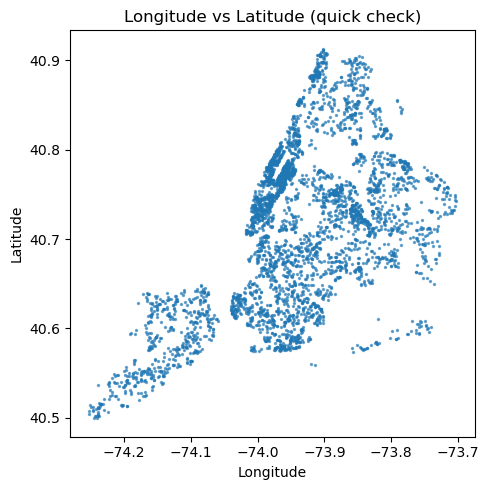

LAT/LONG appear plausible for NYC (quick check).


In [425]:
# Geo-validation checks for LATITUDE / LONGITUDE
import matplotlib.pyplot as plt
from IPython.display import display

# Ensure columns exist
for c in ['LATITUDE','LONGITUDE']:
    if c not in merged_df.columns:
        print(f'Column {c} not present in merged_df')

if set(['LATITUDE','LONGITUDE']).issubset(merged_df.columns):
    # 1) dtype & missing
    print('dtype LAT/LON:', merged_df['LATITUDE'].dtype, merged_df['LONGITUDE'].dtype)
    print('missing LAT/LON:', merged_df[['LATITUDE','LONGITUDE']].isna().sum().to_dict())

    # 2) NYC plausible range check
    nyc_lat_min, nyc_lat_max = 40.4774, 40.9176
    nyc_lon_min, nyc_lon_max = -74.2591, -73.7004
    outside = merged_df[~merged_df['LATITUDE'].between(nyc_lat_min, nyc_lat_max) | ~merged_df['LONGITUDE'].between(nyc_lon_min, nyc_lon_max)]
    print('Rows outside NYC bounds:', outside.shape[0])
    if not outside.empty:
        display(outside.head())

    # 3) duplicates & zero coords
    print('duplicate coordinate rows:', merged_df.duplicated(subset=['LATITUDE','LONGITUDE']).sum())
    print('zero coords count:', int(((merged_df['LATITUDE']==0)|(merged_df['LONGITUDE']==0)).sum()))

    # 4) quick scatter to inspect distribution
    plt.figure(figsize=(5,5))
    plt.scatter(merged_df['LONGITUDE'], merged_df['LATITUDE'], s=2, alpha=0.6)
    plt.title('Longitude vs Latitude (quick check)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

    # 5) short recommendation print
    if outside.shape[0] > 0 or merged_df.duplicated(subset=['LATITUDE','LONGITUDE']).sum() > 0:
        print('Recommendation: inspect and correct out-of-range or duplicate coordinates. Consider re-geocoding or dropping obvious invalid points.')
    else:
        print('LAT/LONG appear plausible for NYC (quick check).')

DEBUG: merged_df_after_cleaning present = True
DEBUG: merged_df present = True
DEBUG: merged_df_after_cleaning.shape = (4200, 25)
DEBUG: merged_df.shape = (4039, 12)
Rows before cleaning: 4,200
Rows after cleaning : 4,039
Rows removed        : 161 (3.8%)

Top 10 columns by absolute missing-value change:

Top 10 columns by absolute missing-value change:


,Before Missing,After Missing,Delta
ZIPCODE,1,0,-1
PROPERTY_TYPE,1,0,-1
TYPE,0,0,0
PRICE,0,0,0
BEDROOMS,0,0,0
BATHROOMS,0,0,0
SQFT,0,0,0
LATITUDE,0,0,0
LONGITUDE,0,0,0



Duplicate rows before: 0
Duplicate rows after : 0

Sample unique-value changes (top 10):


,Unique Before,Unique After
LATITUDE,4196,4035
LONGITUDE,4118,3966
PRICE,1205,1107
SQFT,1362,1264
BEDROOMS,27,19
BATHROOMS,22,17
ZIPCODE,183,182
TYPE,13,13
PROPERTY_TYPE,2,2



Numeric summary (before -> after) for key metrics:


,mean_before,median_before,std_before,mean_after,median_after,std_after
PRICE,2.476243e+06,849998.500000,3.350511e+07,1268701.404308,815000.0,1405899.182339
BEDROOMS,3.475476e+00,3.000000,2.694294e+00,3.324338,3.0,2.153537
BATHROOMS,2.437512e+00,2.000000,2.018071e+00,2.285522,2.0,1.441516
SQFT,2.225780e+03,2184.207862,2.365112e+03,1997.715771,2184.0,1169.81961
LATITUDE,4.071176e+01,40.723250,8.823699e-02,40.710399,40.721085,0.08911
LONGITUDE,-7.394249e+01,-73.948818,1.025321e-01,-73.941103,-73.946349,0.103983


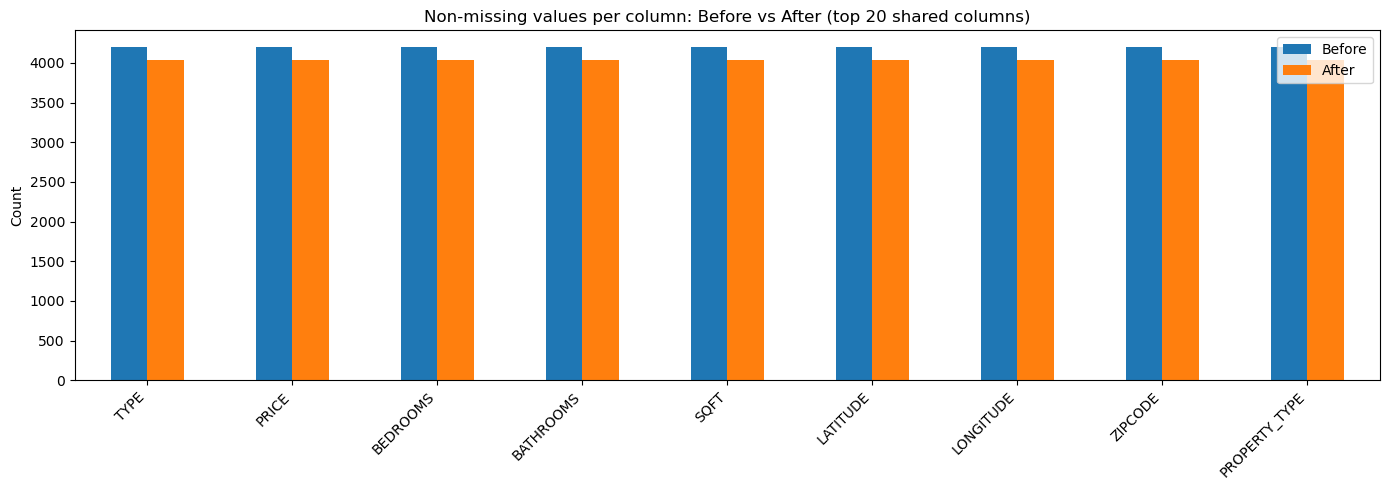


Takeaway:  No major data loss detected.


In [426]:
# -------------------------------
# Compact Before/After Cleaning Comparison (pre vs post final cleaning)
# -------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Get references to pre/post-clean data (non-destructive)
before_df = globals().get('merged_df_after_cleaning')
after_df = globals().get('merged_df')
# Debug prints to ensure variables are present in the notebook kernel
print('DEBUG: merged_df_after_cleaning present =', 'merged_df_after_cleaning' in globals())
print('DEBUG: merged_df present =', 'merged_df' in globals())
if 'merged_df_after_cleaning' in globals():
    print('DEBUG: merged_df_after_cleaning.shape =', globals()['merged_df_after_cleaning'].shape)
if 'merged_df' in globals():
    print('DEBUG: merged_df.shape =', globals()['merged_df'].shape)
if before_df is None or after_df is None:
    print('One or both comparison DataFrames not found. Ensure merged_df_after_cleaning and merged_df exist.')
else:
    # Shapes and row removal summary
    rows_before = before_df.shape[0]
    rows_after = after_df.shape[0]
    removed = rows_before - rows_after
    pct_removed = (removed / rows_before * 100) if rows_before>0 else 0
    print(f'Rows before cleaning: {rows_before:,}')
    print(f'Rows after cleaning : {rows_after:,}')
    print(f'Rows removed        : {removed:,} ({pct_removed:.1f}%)')

    # Shared columns for fair comparison
    shared_cols = [c for c in before_df.columns if c in after_df.columns]
    if not shared_cols:
        print('No shared columns between before and after DataFrames to compare.')
    else:
        # Missing value delta (show top changes)
        before_missing = before_df[shared_cols].isna().sum()
        after_missing = after_df[shared_cols].isna().sum()
        missing_delta = (after_missing - before_missing).abs().sort_values(ascending=False)
        missing_change = pd.DataFrame({'Before Missing': before_missing, 'After Missing': after_missing, 'Delta': (after_missing - before_missing)})
        print('\nTop 10 columns by absolute missing-value change:')
        display(missing_change.loc[missing_delta.index].head(10))

        # Duplicates summary
        dup_before = before_df.duplicated().sum()
        dup_after = after_df.duplicated().sum()
        print(f'\nDuplicate rows before: {dup_before}')
        print(f'Duplicate rows after : {dup_after}')

        # Unique values sample (top 10 by change)
        uniq_before = before_df[shared_cols].nunique()
        uniq_after = after_df[shared_cols].nunique()
        uniq_change = (uniq_after - uniq_before).abs().sort_values(ascending=False)
        uniq_comp = pd.DataFrame({'Unique Before': uniq_before, 'Unique After': uniq_after})
        print('\nSample unique-value changes (top 10):')
        display(uniq_comp.loc[uniq_change.index].head(10))

        # Compact descriptive stats (numeric only)
        print('\nNumeric summary (before -> after) for key metrics:')
        num_cols = before_df.select_dtypes(include=['number']).columns.intersection(after_df.select_dtypes(include=['number']).columns)
        if len(num_cols)>0:
            before_desc = before_df[num_cols].describe().T[['mean','50%','std']].rename(columns={'50%':'median'})
            after_desc = after_df[num_cols].describe().T[['mean','50%','std']].rename(columns={'50%':'median'})
            comp_desc = before_desc.join(after_desc, lsuffix='_before', rsuffix='_after')
            display(comp_desc.head(10))
        else:
            print('No numeric columns to summarize.')

        # Bar plot: Non-missing counts per shared column (Before vs After) - keep top 20 columns by 'Before' count for readability
        before_non_missing = before_df[shared_cols].notna().sum()
        after_non_missing = after_df[shared_cols].notna().sum()
        comp_nm = pd.DataFrame({'Before': before_non_missing, 'After': after_non_missing})
        comp_nm = comp_nm.sort_values('Before', ascending=False).head(20)
        ax = comp_nm.plot(kind='bar', figsize=(14,5))
        ax.set_title('Non-missing values per column: Before vs After (top 20 shared columns)')
        ax.set_ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # One-line takeaway (simple rules)
        takeaway = []
        if pct_removed>10: takeaway.append(f'{pct_removed:.1f}% rows removed')
        high_missing_cols = missing_change[missing_change['Delta'].abs() > (0.05*rows_before)].index.tolist()
        if high_missing_cols: takeaway.append(f'{len(high_missing_cols)} columns lost >5% values')
        if not takeaway: takeaway_text = 'No major data loss detected.'
        else: takeaway_text = '; '.join(takeaway)
        print('\nTakeaway: ', takeaway_text)

## Before/After Cleaning Comparison and Interpretation
This section compares the merged dataset immediately after merging (pre-final cleaning) with the final cleaned dataset. It reports:
- Rows (shape) before and after cleaning
- Missing values per column before and after
- Duplicate row counts before and after
- Unique value counts per column before and after
- A bar plot comparing non-missing value counts per shared column (visual)

The goal is to give a concise, reproducible snapshot of how many rows/values were removed or changed by cleaning and to help decide if any cleaning step was too aggressive.

In [427]:
# -------------------------------
# Final validations (baseline only) & manifest
# -------------------------------
print('Running final baseline validations...')
import json, os

# ZIPCODE normalization (idempotent)
if 'ZIPCODE' in merged_df.columns:
    merged_df['ZIPCODE'] = merged_df['ZIPCODE'].astype(str).str.extract(r'(\d{5})')[0].fillna('')

# Assert key numeric columns
assert 'PRICE' in merged_df.columns and merged_df['PRICE'].gt(0).all(), 'PRICE missing or non-positive values present'
if 'SQFT' in merged_df.columns:
    assert merged_df['SQFT'].gt(0).all(), 'SQFT has non-positive values'

# Outlier counts (report only) for awareness
def iqr_outliers_count(s):
    s2 = s.dropna()
    if s2.empty: return 0
    q1 = s2.quantile(0.25); q3 = s2.quantile(0.75); iqr = q3 - q1
    return int(((s2 < (q1 - 3*iqr)) | (s2 > (q3 + 3*iqr))).sum())
for c in ['PRICE','SQFT']:
    if c in merged_df.columns:
        print(f'{c} outliers (IQR*3 rule):', iqr_outliers_count(merged_df[c]))

manifest = {
    'stage': 'clean_baseline',
    'rows': int(merged_df.shape[0]),
    'cols': int(merged_df.shape[1]),
    'columns': merged_df.columns.tolist(),
    'columns_note': 'Includes PROPERTY_TYPE_GROUP if source PROPERTY_TYPE available',
    'exported_at': pd.Timestamp.utcnow().isoformat(),
    'sample_head': merged_df.head(5).to_dict(orient='records')
}
manifest_path = os.path.join('Resources','NY-House-Dataset-Cleaned-manifest.json')
with open(manifest_path,'w',encoding='utf-8') as f:
    json.dump(manifest,f,ensure_ascii=False,indent=2)
print('Baseline manifest written to', manifest_path)

key_cols = [c for c in ['PRICE','SQFT','BEDROOMS','BATHROOMS'] if c in merged_df.columns]
print('Nulls in key modeling columns:', int(merged_df[key_cols].isnull().sum().sum()))

Running final baseline validations...
PRICE outliers (IQR*3 rule): 196
SQFT outliers (IQR*3 rule): 90
Baseline manifest written to Resources\NY-House-Dataset-Cleaned-manifest.json
Nulls in key modeling columns: 0


In [428]:
merged_df

,TYPE,PRICE,BEDROOMS,BATHROOMS,SQFT,LATITUDE,LONGITUDE,ZIPCODE,BOROUGH,SUBLOCALITY,PROPERTY_TYPE,PROPERTY_TYPE_GROUP
0,condo,315000,2,2.0,1400,40.761255,-73.974483,10022,manhattan,midtown east,amenity,other
1,house,260000,4,2.0,2015,40.541805,-74.196109,10312,staten island,richmond county,building,residential
2,condo,69000,3,1.0,445,40.761398,-73.974613,10022,manhattan,midtown east,amenity,other
3,house,690000,5,2.0,4004,40.674363,-73.958725,11238,brooklyn,kings county,building,residential
4,condo,899500,2,2.0,2184,40.809448,-73.946777,10027,manhattan,harlem,building,residential
...,...,...,...,...,...,...,...,...,...,...,...,...
4034,condo,945000,2,2.0,903,40.816711,-73.942050,10030,NaN,central harlem,amenity,other
4035,multi-family home,2999999,15,9.0,3600,40.578450,-73.982739,11224,NaN,coney island,building,residential
4036,co-op,599000,1,1.0,2184,40.774350,-73.955879,10075,NaN,new york,building,residential
4037,co-op,1275000,1,1.0,2184,40.745882,-74.003398,10011,manhattan,new york county,building,residential


In [429]:
# Unique SUBLOCALITY values (after coalescing)
if 'SUBLOCALITY' in merged_df.columns:
    merged_df['SUBLOCALITY'].unique()
else:
    print('SUBLOCALITY column not present.')

In [430]:
# Export the cleaned baseline data to CSV for downstream feature engineering
cleaned_data_path = 'Resources/NY-House-Dataset-Cleaned.csv'
merged_df.to_csv(cleaned_data_path, index=False)
print(f'Clean baseline data exported to {cleaned_data_path}')

Clean baseline data exported to Resources/NY-House-Dataset-Cleaned.csv


In [431]:
# Final Baseline Export (Guaranteed NA-Free)
from pathlib import Path, PurePath
import json, datetime

# Work on a copy to avoid mutating upstream reference unexpectedly
baseline_export = merged_df.copy()
na_count = int(baseline_export.isna().sum().sum())
if na_count != 0:
    print(f'Info: Baseline had {na_count} residual NA cells. Dropping rows with any NA to enforce cleanliness.')
    before_rows = len(baseline_export)
    baseline_export = baseline_export.dropna(axis=0, how='any')
    after_rows = len(baseline_export)
    print(f'Removed {before_rows - after_rows} rows; new shape: {baseline_export.shape}')
else:
    print('Baseline already NA-free.')

export_dir = Path('Resources')
export_dir.mkdir(exist_ok=True)

clean_path = export_dir / 'NY-House-Dataset-Cleaned.csv'
man_path = export_dir / 'NY-House-Dataset-Cleaned.manifest.json'

baseline_export.to_csv(clean_path, index=False)
print(f'✅ Baseline cleaned dataset written to {clean_path} ({len(baseline_export)} rows).')

manifest = {
    'export_timestamp': datetime.datetime.utcnow().isoformat()+'Z',
    'rows': len(baseline_export),
    'columns': baseline_export.shape[1],
    'column_order': list(baseline_export.columns),
    'dtypes': {c: str(baseline_export[c].dtype) for c in baseline_export.columns},
    'na_cells_after_export': int(baseline_export.isna().sum().sum()),
    'sample': baseline_export.head(5).to_dict(orient='records')
}
with open(man_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)
print(f'Manifest written to {man_path}')

Info: Baseline had 923 residual NA cells. Dropping rows with any NA to enforce cleanliness.
Removed 923 rows; new shape: (3116, 12)
✅ Baseline cleaned dataset written to Resources\NY-House-Dataset-Cleaned.csv (3116 rows).
Manifest written to Resources\NY-House-Dataset-Cleaned.manifest.json


### Final Triple Export Blocks
Below: (1) Summary review, (2) Validation ensuring zero missing values & schema, (3) CSV export to `Resources/NY-House-Dataset-Cleaned.csv`. Run in order.

In [432]:
# (2) Validation Cell: verify zero NA and display schema & basic stats
import pandas as pd, json, textwrap
from pathlib import Path

# Assume merged_df exists & baseline already finalized into merged_df
validation_df = merged_df.copy()

na_counts = validation_df.isna().sum()
total_na = int(na_counts.sum())

print('Total rows:', len(validation_df))
print('Total columns:', validation_df.shape[1])
print('Total remaining NA cells:', total_na)
if total_na == 0:
    print('\n✅ Dataset is NA-free.')
else:
    print('\n⚠️ Dataset still has NA values. Top offenders:')
    print(na_counts[na_counts>0].sort_values(ascending=False).head())

print('\nColumn dtypes:')
print(validation_df.dtypes)

print('\nQuick numeric summary:')
print(validation_df.describe(include='number').T[['mean','std','min','max']].round(2).head(15))

print('\nSample rows:')
print(validation_df.head(3))

Total rows: 4039
Total columns: 12
Total remaining NA cells: 923

⚠️ Dataset still has NA values. Top offenders:
BOROUGH    923
dtype: int64

Column dtypes:
TYPE                    object
PRICE                    int64
BEDROOMS                 Int64
BATHROOMS              float64
SQFT                     Int64
LATITUDE               float64
LONGITUDE              float64
ZIPCODE                 object
BOROUGH                 object
SUBLOCALITY             object
PROPERTY_TYPE           object
PROPERTY_TYPE_GROUP     object
dtype: object

Quick numeric summary:
                     mean             std        min        max
PRICE      1268701.404308  1405899.182339    49500.0  9999000.0
BEDROOMS         3.324338        2.153537        1.0       20.0
BATHROOMS        2.285522        1.441516        0.0       20.0
SQFT          1997.715771      1169.81961      230.0    17860.0
LATITUDE        40.710399         0.08911  40.499546  40.912729
LONGITUDE      -73.941103        0.103983 -74.253

In [433]:
# (3) Export Cell: write NA-free cleaned dataset & manifest
from pathlib import Path
import json, datetime

export_df = merged_df.copy()

# Safety: drop any residual NA rows just in case
pre_rows = len(export_df)
export_df = export_df.dropna(axis=0, how='any')
post_rows = len(export_df)
if post_rows < pre_rows:
    print(f'Removed {pre_rows - post_rows} rows with late-stage NA values.')

out_dir = Path('Resources')
out_dir.mkdir(exist_ok=True)
clean_path = out_dir / 'NY-House-Dataset-Cleaned.csv'
manifest_path = out_dir / 'NY-House-Dataset-Cleaned.manifest.json'

export_df.to_csv(clean_path, index=False)
print(f'✅ Clean dataset written to {clean_path} ({post_rows} rows).')

manifest = {
    'export_timestamp': datetime.datetime.utcnow().isoformat()+'Z',
    'rows': post_rows,
    'columns': export_df.shape[1],
    'column_order': list(export_df.columns),
    'dtypes': {c: str(export_df[c].dtype) for c in export_df.columns},
    'sample': export_df.head(5).to_dict(orient='records')
}
with open(manifest_path,'w',encoding='utf-8') as f:
    json.dump(manifest,f,indent=2)
print(f'Manifest written to {manifest_path}')

Removed 923 rows with late-stage NA values.
✅ Clean dataset written to Resources\NY-House-Dataset-Cleaned.csv (3116 rows).
Manifest written to Resources\NY-House-Dataset-Cleaned.manifest.json


In [ ]:
# Strict NaN/Null Purge (Final Assurance)
import pandas as pd, numpy as np

def enforce_no_nans(df: pd.DataFrame, name: str) -> pd.DataFrame:
    before_rows = df.shape[0]
    df = df.replace(['nan','NaN','None','null','NULL'], np.nan)
    df_clean = df.dropna(axis=0, how='any')
    dropped = before_rows - df_clean.shape[0]
    if df_clean.isna().sum().sum() != 0:
        raise ValueError(f"Still NaNs in {name} after purge.")
    print(f"[{name}] Dropped {dropped} rows to remove all NaNs. Final shape: {df_clean.shape}")
    return df_clean

if 'merged_df' in globals():
    merged_df = enforce_no_nans(merged_df, 'baseline')
if 'feature_df' in globals():
    feature_df = enforce_no_nans(feature_df, 'feature_df')

if 'merged_df' in globals():
    print('Baseline NaNs remaining:', int(merged_df.isna().sum().sum()))


[baseline] Dropped 923 rows to remove all NaNs. Final shape: (3116, 12)
[feature_df] Dropped 0 rows to remove all NaNs. Final shape: (4039, 14)
Baseline NaNs remaining: 0
Feature DF NaNs remaining: 0


## Recommended Pre-Feature-Engineering Enhancements
The following steps refine the cleaned baseline prior to modeling feature engineering:
1. Re-standardize and validate categorical columns (TYPE, PROPERTY_TYPE, PROPERTY_TYPE_GROUP).
2. Deduplicate rows on (LATITUDE, LONGITUDE, PRICE).
3. Cap numeric outliers (PRICE, SQFT, BEDROOMS, BATHROOMS) using winsorization (1st/99th pct) without dropping rows.
4. Infer missing BOROUGHs from ZIPCODE patterns (Manhattan 100/101/102, Bronx 104, Brooklyn 112, Queens 110(04-05)/111/113/114/116, Staten Island 103).
5. Decide whether to drop a redundant property category column (drops PROPERTY_TYPE if PROPERTY_TYPE_GROUP provides same information or vice versa).
6. Create derived features: PRICE_PER_SQFT, LOG_PRICE, LOG_PRICE_PER_SQFT.
7. Final purge of any remaining NaNs in modeling columns (rows dropped only if critical modeling fields still null).
8. Export a feature-ready dataset and manifest.
